# SupplyMind AI — Business Data Analysis

## Objective

Reproduce the rich, business-oriented analysis style of the reference
notebook using SynDelay fields. Each table or chart is followed by a short
interpretation and an engineering implication.

In [1]:
# -------------------
# Imports
# -------------------

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from supplymind.features.predictions.domain.constants import (
    CATEGORICAL_FEATURES,
    NUMERICAL_FEATURES,
    TARGET_COLUMN,
)
from supplymind.features.predictions.ml.workflow import load_clean_syndelay

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
# -------------------
# Project configuration
# -------------------

DATASET_PATH = Path("../data/raw/syndelay/syndelay_v1.csv")
REPORT_ROOT = Path("../reports")

assert DATASET_PATH.exists(), (
    f"Dataset not found: {DATASET_PATH}"
)

In [3]:
df = load_clean_syndelay(DATASET_PATH)

## 1. Sales by delivery outcome

,total_sales
label,
Delayed,1.807970e+07
Early,7.441925e+06
On-time,5.858658e+06


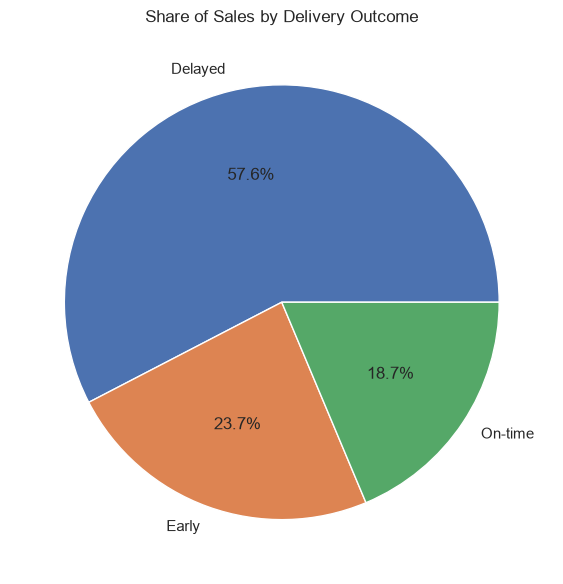

In [4]:
sales_by_outcome = (
    df.groupby("label", observed=True)["sales"]
    .sum()
    .rename(index={0: "Early", 1: "On-time", 2: "Delayed"})
    .sort_values(ascending=False)
)

display(sales_by_outcome.to_frame("total_sales"))

sales_by_outcome.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6, 6),
    title="Share of Sales by Delivery Outcome",
    ylabel="",
)
plt.tight_layout()
plt.show()

### Analysis

This view quantifies how much commercial value is associated with each
delivery outcome. If delayed orders account for a large share of sales, delay
prediction is not only an operational problem but also a material revenue-risk
problem.

**Engineering implication:** keep order-value features for modelling, but avoid
interpreting correlation as causation.

## 2. Sales by market

,total_sales
market,
Europe,9.322228e+06
LATAM,8.350845e+06
Pacific Asia,7.083637e+06
USCA,4.509175e+06
Africa,2.114401e+06


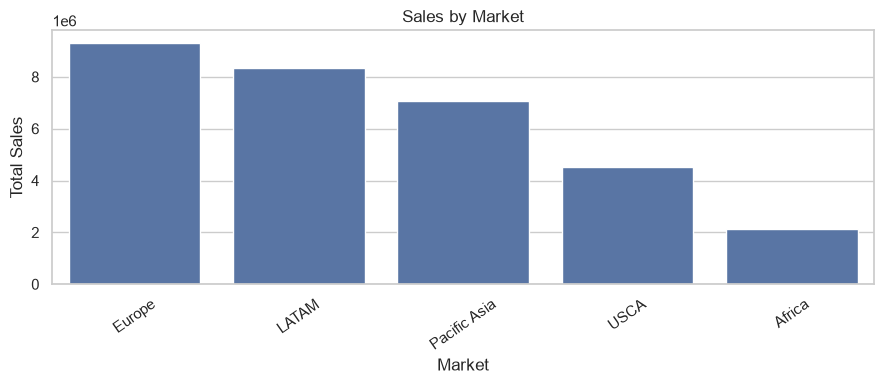

In [5]:
sales_by_market = (
    df.groupby("market", observed=True)["sales"]
    .sum()
    .sort_values(ascending=False)
)

display(sales_by_market.to_frame("total_sales"))

plt.figure(figsize=(9, 4))
sns.barplot(
    x=sales_by_market.index,
    y=sales_by_market.values,
)
plt.title("Sales by Market")
plt.ylabel("Total Sales")
plt.xlabel("Market")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

### Analysis

Market volume provides context for delay rates. A high delay rate in a very
small market may have less operational impact than a moderate delay rate in a
market representing a large share of sales.

**Engineering implication:** `market` is a meaningful categorical candidate
and is retained for one-hot encoding.

## 3. Top product categories by sales

,total_sales
category_name,
Fishing,5.925607e+06
Cleats,3.926892e+06
Camping & Hiking,3.536953e+06
Cardio Equipment,3.226274e+06
Women's Apparel,2.681035e+06
Water Sports,2.659818e+06
Men's Footwear,2.515181e+06
Indoor/Outdoor Games,2.503262e+06
Shop By Sport,1.075247e+06


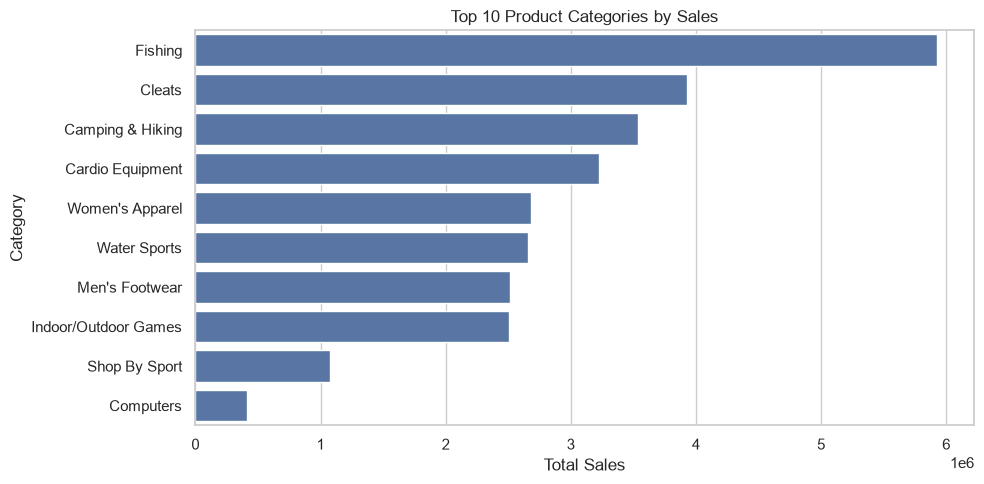

In [6]:
top_categories = (
    df.groupby("category_name", observed=True)["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_categories.to_frame("total_sales"))

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_categories.values,
    y=top_categories.index,
)
plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Analysis

Product mix can expose structural differences in fulfillment complexity.
High-volume categories deserve particular attention because even a modest
delay rate can affect many customers and significant revenue.

**Engineering implication:** retain `category_name`; treat any observed
relationship as dataset-level association rather than causal evidence.

## 4. Regions associated with negative profit

,sales_on_negative_profit_orders
order_region,
Western Europe,914336.359104
Central America,754242.332045
South America,493462.020278
Southern Europe,319299.909415
Northern Europe,307170.112219
South Asia,295846.426485
Oceania,291980.539805
Eastern Asia,260826.369909
Southeast Asia,256866.334988


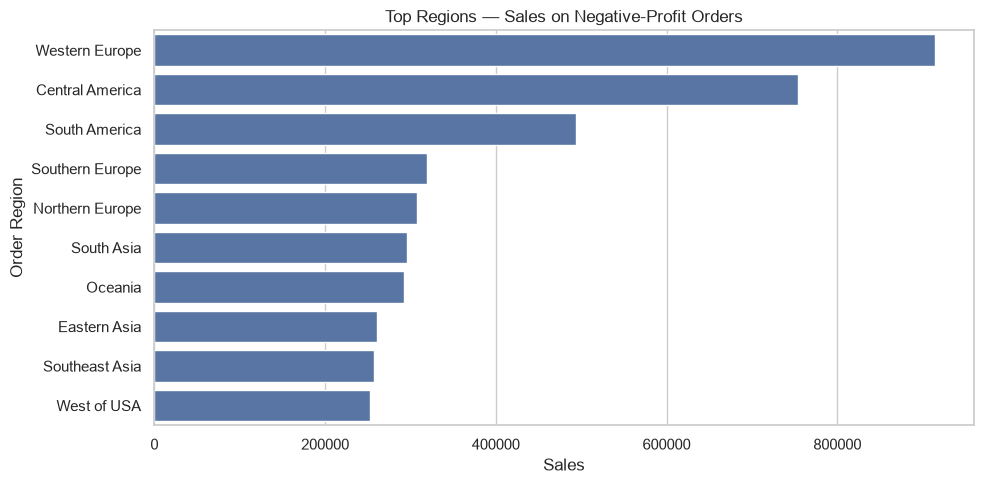

In [7]:
negative_profit = df[df["order_profit_per_order"] < 0]

loss_regions = (
    negative_profit.groupby("order_region", observed=True)["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(loss_regions.to_frame("sales_on_negative_profit_orders"))

plt.figure(figsize=(10, 5))
sns.barplot(
    x=loss_regions.values,
    y=loss_regions.index,
)
plt.title("Top Regions — Sales on Negative-Profit Orders")
plt.xlabel("Sales")
plt.ylabel("Order Region")
plt.tight_layout()
plt.show()

### Analysis

This does not mean these regions *cause* losses. It shows where negative-profit
orders carry the greatest commercial exposure.

**Engineering implication:** profit variables and region can both be useful
predictive context, but the model should later be monitored for geography-
specific bias or instability.

## 5. Payment type vs delay risk

is_delayed,Not delayed,Delayed
payment_type,,
CASH,7479,10045
DEBIT,26409,35694
PAYMENT,15929,22090
TRANSFER,15962,21880


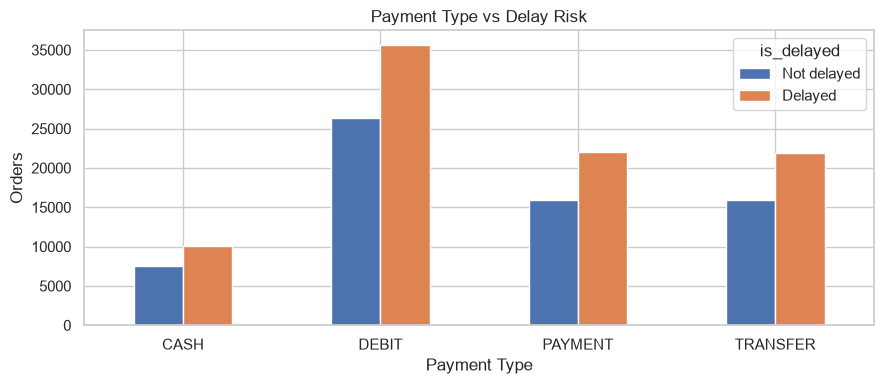

In [8]:
payment_delay = pd.crosstab(
    df["payment_type"],
    df[TARGET_COLUMN],
).rename(columns={0: "Not delayed", 1: "Delayed"})

display(payment_delay)

payment_delay.plot(
    kind="bar",
    figsize=(9, 4),
    title="Payment Type vs Delay Risk",
)
plt.ylabel("Orders")
plt.xlabel("Payment Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Analysis

Differences between payment groups may reflect business-process relationships
in the source dataset rather than a direct logistics mechanism.

**Engineering implication:** payment type can remain as a low-cardinality
categorical feature, while interpretation should stay non-causal.

## 6. Department volume by shipping mode

shipping_mode,First Class,Same Day,Second Class,Standard Class
department_name,,,,
Apparel,6524,2288,8602,25420
Book Shop,44,18,61,197
Discs Shop,249,90,330,1062
Fan Shop,8796,2845,11597,34357
Fitness,286,83,374,1114
Footwear,1923,695,2565,7817
Golf,4283,1442,5536,16745
Health and Beauty,54,20,89,241
Outdoors,1244,417,1607,5017


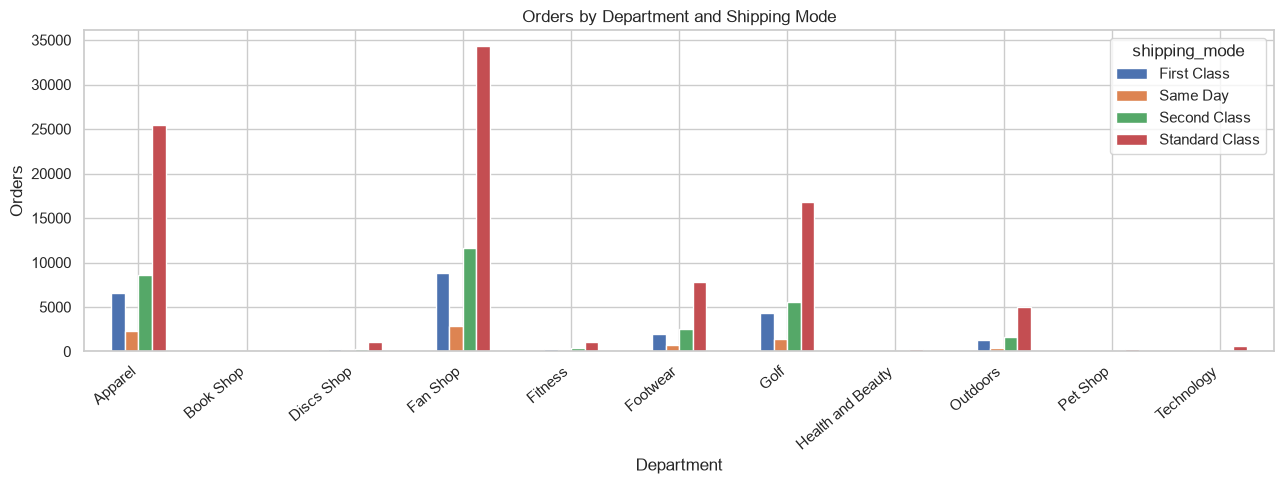

In [9]:
department_shipping = pd.crosstab(
    df["department_name"],
    df["shipping_mode"],
)

display(department_shipping)

department_shipping.plot(
    kind="bar",
    figsize=(13, 5),
    title="Orders by Department and Shipping Mode",
)
plt.ylabel("Orders")
plt.xlabel("Department")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

### Analysis

This chart reveals whether certain departments rely disproportionately on
particular service levels. Such operational structure can explain why shipping
mode becomes predictive even without implying a causal effect.

## 7. Delay risk by shipping mode

is_delayed,Not delayed,Delayed
shipping_mode,,
First Class,0.00,100.00
Same Day,49.82,50.18
Second Class,20.74,79.26
Standard Class,59.64,40.36


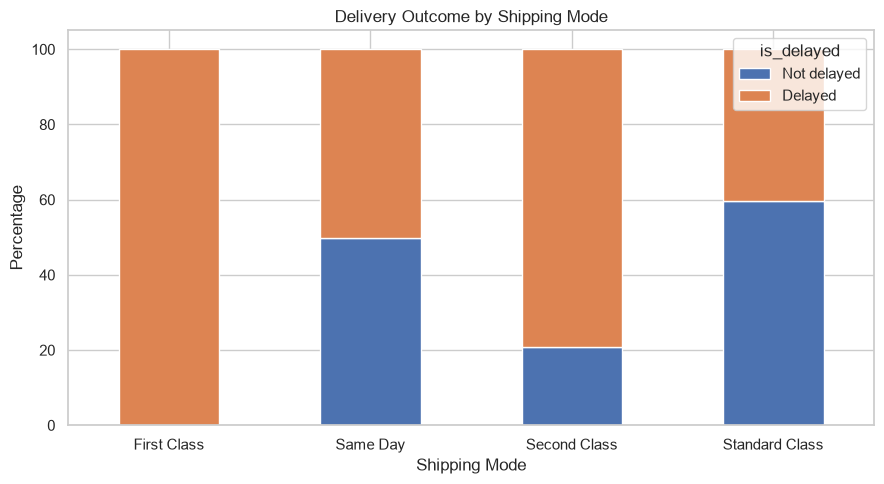

In [10]:
shipping_delay = pd.crosstab(
    df["shipping_mode"],
    df[TARGET_COLUMN],
    normalize="index",
).rename(columns={0: "Not delayed", 1: "Delayed"}) * 100

display(shipping_delay.round(2))

shipping_delay.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    title="Delivery Outcome by Shipping Mode",
)
plt.ylabel("Percentage")
plt.xlabel("Shipping Mode")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Analysis

Shipping mode is one of the strongest visible relationships in SynDelay.
However, SynDelay is synthetic and the relationship can reflect source
business rules or generative artifacts.

**Engineering implication:** retain `shipping_mode`, but explicitly monitor its
importance and distribution when SupplyMind moves to real ERP/TMS data.

## 8. Shipping mode × region × delay

,order_region,shipping_mode,orders,delay_rate,sales
91,Western Europe,Standard Class,14801,0.401257,3.009080e+06
15,Central America,Standard Class,12517,0.402333,2.542760e+06
51,South America,Standard Class,8087,0.409175,1.653699e+06
71,Southern Europe,Standard Class,5226,0.389591,1.040947e+06
43,Northern Europe,Standard Class,4992,0.402244,1.014738e+06
90,Western Europe,Second Class,4974,0.789103,1.004265e+06
47,Oceania,Standard Class,4501,0.393690,8.906919e+05
55,South Asia,Standard Class,4415,0.411099,8.874019e+05
31,Eastern Asia,Standard Class,4292,0.407269,8.700129e+05
14,Central America,Second Class,4132,0.780736,8.358626e+05


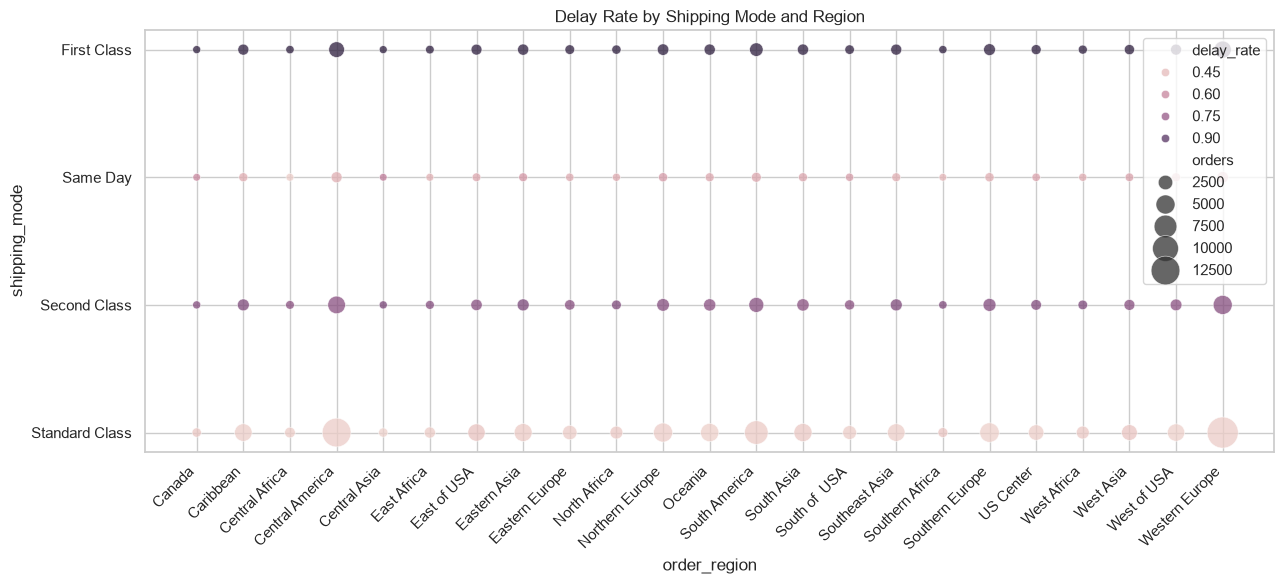

In [11]:
region_mode = (
    df.groupby(
        ["order_region", "shipping_mode"],
        observed=True,
    )
    .agg(
        orders=(TARGET_COLUMN, "size"),
        delay_rate=(TARGET_COLUMN, "mean"),
        sales=("sales", "sum"),
    )
    .reset_index()
)

display(
    region_mode.sort_values(
        ["orders", "delay_rate"],
        ascending=[False, False],
    ).head(30)
)

plt.figure(figsize=(13, 6))
sns.scatterplot(
    data=region_mode,
    x="order_region",
    y="shipping_mode",
    hue="delay_rate",
    size="orders",
    sizes=(30, 500),
    alpha=0.75,
)
plt.xticks(rotation=45, ha="right")
plt.title("Delay Rate by Shipping Mode and Region")
plt.tight_layout()
plt.show()

### Analysis

This bubble view combines operational volume and delay risk. Large bubbles with
high delay rates identify combinations that deserve the most attention.

**Product implication:** this type of aggregation can later feed SupplyMind's
dashboard and route-risk views.

## 9. Geographic delay map

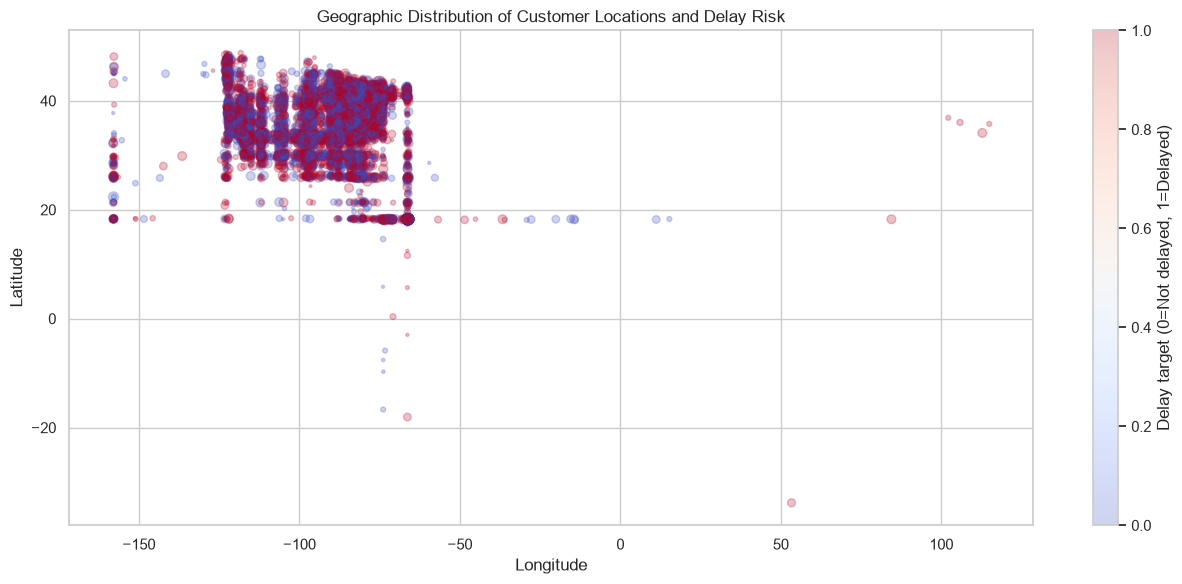

In [12]:
# Sample points for readable plotting.
geo_sample = df.sample(
    n=min(30_000, len(df)),
    random_state=42,
)

plt.figure(figsize=(13, 6))
scatter = plt.scatter(
    geo_sample["longitude"],
    geo_sample["latitude"],
    c=geo_sample[TARGET_COLUMN],
    s=np.clip(geo_sample["sales"] / 10, 4, 60),
    alpha=0.25,
    cmap="coolwarm",
)
plt.colorbar(
    scatter,
    label="Delay target (0=Not delayed, 1=Delayed)",
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Customer Locations and Delay Risk")
plt.tight_layout()
plt.show()

### Analysis

This is a geographic scatter rather than a routing map. It helps identify
geographic concentration and whether delayed orders appear spatially clustered.

**Caution:** latitude/longitude represent source-record locations and should not
be interpreted as exact shipment trajectories.

**Product implication:** the operational Event Monitor will later use real map
layers and external disruption coordinates rather than this EDA visualization.

## 10. Temporal delay trend

,orders,delay_rate,sales
month,,,
2015-01,4811,0.584702,953624.778448
2015-02,3984,0.582078,772386.377361
2015-03,4105,0.567600,799559.487594
2015-04,3714,0.573775,726879.373469
2015-05,3910,0.574169,763779.067586


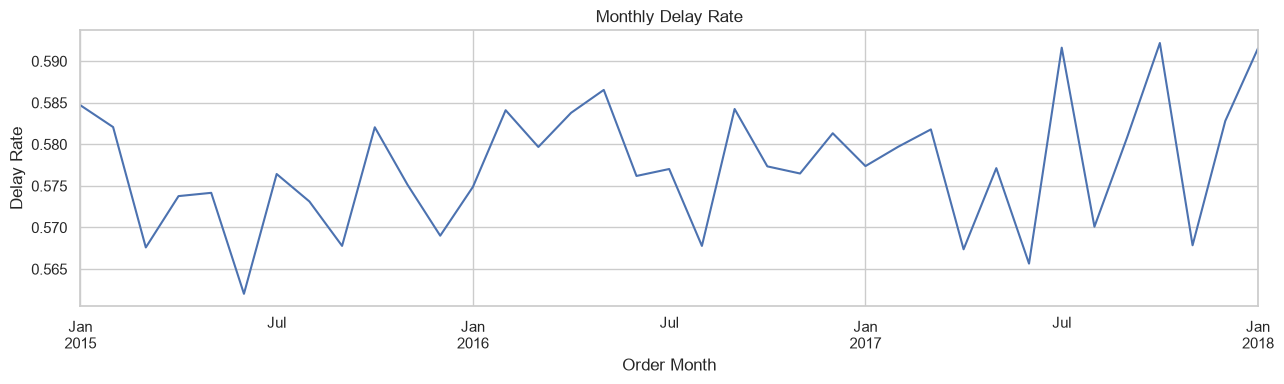

In [13]:
monthly = (
    df.assign(month=df["order_date"].dt.to_period("M"))
    .groupby("month", observed=True)
    .agg(
        orders=(TARGET_COLUMN, "size"),
        delay_rate=(TARGET_COLUMN, "mean"),
        sales=("sales", "sum"),
    )
)

display(monthly.head())

monthly["delay_rate"].plot(
    figsize=(13, 4),
    title="Monthly Delay Rate",
)
plt.ylabel("Delay Rate")
plt.xlabel("Order Month")
plt.tight_layout()
plt.show()

### Analysis

Temporal variation matters because SupplyMind will be deployed on future data.
If the delay rate changes over time, a random split can hide degradation.

**Engineering implication:** use a chronological split and later monitor class
distribution and model performance over time.